**Project Title:** Digital media consumption and market trends\
**Author:** Maverick Luke \
**Date:** April 23rd, 2025 

# Imports and Constants

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime, timedelta
from time import sleep
import yfinance as yf
import praw
import re
import statsmodels.api as sm
from scipy.stats import ttest_1samp, ttest_ind, pearsonr, spearmanr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px
from IPython.display import HTML
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [16]:
# Constants for retrieving data from APIs (not necessary to run the code)
# These constants are used to store the API keys and other sensitive information
with open('tmdb_api_key.txt', 'r') as file:
    for line in file:
        clean_line = line.strip()
        if clean_line:
            API_KEY = clean_line # your api key (can be obtained from https://github.com/rickylawson/freekeys/blob/master/index.js)
            break

with open('reddit_client.txt', 'r') as file:
    lines = file.readlines()
    CLIENT_ID = lines[0].strip() # your client id 
    CLIENT_SECRET = lines[1].strip() # your client secret
    USER_AGENT = lines[2].strip() # python:JSC370.project:v1.0 (by /u/YOUR_REDDIT_USERNAME)

# Introduction

The streaming media landscape has evolved dramatically in recent years, with platforms like Netflix and Disney+ competing intensely for subscribers. Original content has become a primary differentiator in this competition, with platforms investing billions in developing exclusive shows and movies. Meanwhile, social media platforms like Reddit serve as immediate indicators of audience reception, potentially signaling a release's success or failure. This intersection of streaming content strategies and social media engagement raises an important question for investors: How do major content releases on these platforms affect their stock market performance, and can social media metrics serve as leading indicators for these market movements?

## Research Question
This project addresses the question: **How do major streaming content releases on Netflix and Disney+ affect their respective stock prices in the short term, and does social media engagement correlate with these market movements?** \
Specifically, we analyze:

1. Whether stock prices show abnormal returns in the 3-day window following content releases
2. Whether Reddit engagement metrics correlate with stock price movements
3. Is the sentiment of Reddit comments about a movie (positive/negative) associated with upward/downward movement in stock price?
4. Is there a lagged relationship between Reddit engagement and provider stock returns (e.g., 1-day, 3-day, 7-day lag)?

# Methods

The study combines data from three distinct sources to examine relationships between streaming content releases, stock market performance, and social media engagement:

- Streaming Content Data: **The Movie Database (TMDB) API** was used to collect information about Netflix and Disney+ releases, including release dates, popularity scores, and genres. Both TV shows and movies were included to ensure a sufficient sample size.
- Stock Market Data: Financial data for Netflix (NFLX), Disney (DIS), and the S&P 500 index was collected using the Yahoo Finance API via the Python **yfinance** package. Daily closing prices, trading volume, and other metrics were gathered for the period from September 2024 to March 2025.
- Social Media Engagement Data: Reddit's API was accessed using the Python **praw** library to collect post and comment data related to each content release. Data was collected from relevant subreddits including r/television, r/netflix, r/DisneyPlus, r/streaming.

## API Implementation
(*Skip to `Read existing CSV files` if the dataframes are available in CSVs*) 

The following code demonstrates how data was collected from each API source: (Note that the API calls take some time and requires API keys (for TMDB) and client id and client secret (for Reddit praw). To improve efficiency, I’ve saved the datasets as CSV files for quicker retrieval. The retrieval code is located right below the API calls functions)

In [63]:
# Function to get the top releases for a given streaming provider
# The function fetches the top TV shows released on the specified streaming platform
def get_top_releases(provider_id, start_date, end_date, api_key = API_KEY):
    base_url_tv = "https://api.themoviedb.org/3/tv/popular"
    base_url_movie = "https://api.themoviedb.org/3/movie/popular"
    
    tv_results = []
    movie_results = []

    page_tv = 1
    page_movie = 1
    max_page = 30
    
    while True:
        params_tv = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'first_air_date.gte': start_date,
            'first_air_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_tv
        }
        params_movie = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'primary_release_date.gte': start_date,
            'primary_release_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_movie
        }

        if page_tv < max_page: 
            response_tv = requests.get(base_url_tv, params_tv)
            data = response_tv.json()
            if 'results' in data:
                tv_results.extend(data['results'])
            page_tv += 1

        if page_movie < max_page:
            response_movie = requests.get(base_url_movie, params_movie)
            data = response_movie.json()
            if 'results' in data:
                movie_results.extend(data['results'])
            page_movie += 1        

        if page_tv >= max_page and page_movie >= max_page:
            break

        sleep(0.5)  
    
    for item in tv_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['content-type'] = 'TV Show'
    
    for item in movie_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['first_air_date'] = item['release_date']
        item['name'] = item['title']
        item['content-type'] = 'Movie'

    return tv_results, movie_results

def get_all_genre_info():
    genre_tv_url = f"https://api.themoviedb.org/3/genre/tv/list"
    genre_movie_url = f"https://api.themoviedb.org/3/genre/movie/list"
    params = {
        'api_key': API_KEY
    }
    response_tv = requests.get(genre_tv_url, params)
    response_movie = requests.get(genre_movie_url, params)
    
    data_tv = response_tv.json()
    data_movie = response_movie.json()

    all_genres = data_tv['genres'] + data_movie['genres']
    all_genres_dict = {genre['id']: genre['name'] for genre in all_genres}

    return all_genres_dict

# Function to get genre information for a given genre ID
# The function returns a list of genre names for the given genre IDs
def get_genre_info(genre_ids, genres_dict):
    genres = []
    for genre_id in genre_ids:
        genre_name = genres_dict.get(genre_id)
        if genre_name:
            genres.append(genre_name)
    return genres


# Get genre information for TV shows and movies
all_genres_dict = get_all_genre_info()
all_genres = list(all_genres_dict.values())

# Fetch top releases for Netflix and Disney+ from 2000 to now
start_date = "2000-01-01" 
end_date = str(datetime.now().strftime("%Y-%m-%d"))

netflix_releases_tv, netflix_releases_movie = get_top_releases(8, start_date, end_date) # 8 is the ID for Netflix
disney_releases_tv, disney_releases_movie = get_top_releases(337, start_date, end_date) # 337 is the ID for Disney+ 

# Combine the results into a single DataFrame
releases_df_tv = pd.DataFrame(netflix_releases_tv + disney_releases_tv) 
releases_df_movie = pd.DataFrame(netflix_releases_movie + disney_releases_movie)
releases_df = pd.concat([releases_df_tv, releases_df_movie], ignore_index=True)

# Add genre information to the DataFrame
for genre in all_genres_dict.keys():
    releases_df[all_genres_dict[genre]] = releases_df['genre_ids'].apply(lambda x: 1 if genre in x else 0)

releases_df = releases_df[[
    'id', 'name', 'first_air_date', 'popularity', 
    'vote_average', 'vote_count', 'provider', 'provider_id', 'content-type'] + list(all_genres_dict.values())]

releases_df['release_date'] = pd.to_datetime(releases_df['first_air_date'])
releases_df['ticker'] = releases_df['provider'].map({
    'Netflix': 'NFLX',
    'Disney+': 'DIS'
})


In [ ]:
# Filter the DataFrame based on popularity and vote count to get the top releases
min_popularity = 30
min_votes = 1000

print("Before filtering:")
print(f"Number of releases: {len(releases_df)}")
print(f"Date range: {releases_df['release_date'].min()} to {releases_df['release_date'].max()}")
print(f"Top 5 releases:\n{releases_df.head()}")

print("After filtering:")
releases_df = releases_df[
        (releases_df["popularity"] > min_popularity) &
        (releases_df["vote_count"] > min_votes)
    ]

print(f"Number of releases: {len(releases_df)}")
print(f"Date range: {releases_df['release_date'].min()} to {releases_df['release_date'].max()}")
print(f"Top 5 releases:\n{releases_df.head()}")

In [ ]:
# Function to get the stock data for the specified tickers and date range
# The function fetches the stock data for the specified tickers from Yahoo Finance
def get_stock_data(tickers, start_date, end_date):
    # Add buffer to start and end dates
    start_buffer = (pd.to_datetime(start_date) - timedelta(days=14)).strftime('%Y-%m-%d')
    end_buffer = (pd.to_datetime(end_date) + timedelta(days=14)).strftime('%Y-%m-%d')
    
    data = yf.download(tickers, start=start_buffer, end=end_buffer, auto_adjust=False)
    
    # Stack the column indices to create a single level of column labels
    df = data.stack(level=1).reset_index()
    df.columns = ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

    df = df.sort_values(['Ticker', 'Date'])
    # Calculate daily returns for each stock (in percentage)
    df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change() * 100
    return df

tickers = ['NFLX', 'DIS', '^GSPC']  # Netflix, Disney, and S&P 500
start_date = start_date 
end_date = end_date

stock_data = get_stock_data(tickers, start_date, end_date)
# Replace the ticker symbol for S&P 500 with 'SPY'
stock_data.loc[stock_data['Ticker'] == '^GSPC', 'Ticker'] = 'SPY'

In [49]:
# Calculate abnormal returns for each release
def calculate_abnormal_returns(releases, stock_data):
    results = []
    
    for _, release in releases.iterrows():
        ticker = release['ticker']
        release_date = release['release_date']
        
        start_date = release_date
        # Use a 3-day window after the release date to minimize noise
        end_date = release_date + timedelta(days=3)
        
        # Get stock data for this window
        stock_window = stock_data[
            (stock_data['Ticker'] == ticker) & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        # Get market data (S&P 500) for the same window
        market_window = stock_data[
            (stock_data['Ticker'] == 'SPY') & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        if len(stock_window) > 0 and len(market_window) > 0:
            # Calculate cumulative returns
            if len(stock_window) > 1:
                # Use first and last prices
                first_price = stock_window.iloc[0]['Adj Close']
                last_price = stock_window.iloc[-1]['Adj Close']
                stock_return = (last_price - first_price) / first_price * 100
            else:
                stock_return = stock_window.iloc[0]['Daily_Return']
            
            if len(market_window) > 1:
                first_market = market_window.iloc[0]['Adj Close']
                last_market = market_window.iloc[-1]['Adj Close']
                market_return = (last_market - first_market) / first_market * 100
            else:
                market_return = market_window.iloc[0]['Daily_Return']
            
            abnormal_return = stock_return - market_return
            
            result = release.copy()
            result['stock_return'] = stock_return
            result['market_return'] = market_return
            result['abnormal_return'] = abnormal_return
            results.append(result)
    
    return pd.DataFrame(results)

# Change the date to the correct format
releases_df['release_date'] = pd.to_datetime(releases_df['release_date'])
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

returns_df = calculate_abnormal_returns(releases_df, stock_data)

In [33]:
# Function to retrieve engagement data from Reddit for a given movie title and release date
# The function searches for posts related to the movie on specific subreddits
# Caution: This function makes multiple requests to the Reddit API and may take some time to run
def get_reddit_engagement(title, release_date, reddit_client, is_movie=True, is_netflix=True, comment_limit=10):
    if not isinstance(release_date, datetime):
        release_date = pd.to_datetime(release_date)
    
    start_date = release_date - timedelta(days=14)
    end_date = release_date + timedelta(days=14)
    
    search_queries = [
        f'{title} discussion',
    ] 

    # Remove subtitle from the title (if present)
    clean_title = re.sub(r'[:\-–—].*$', '', title).strip()
    if clean_title != title:
        search_queries.append(f'"{clean_title}"')
    
    subreddits = []
    if is_movie:
        subreddits.append('movies')
    else: 
        subreddits.append('television')
    if is_netflix:
        subreddits.append('netflix')
        subreddits.append('NetflixBestOf')
    else:
        subreddits.append('DisneyPlus')
    
    all_posts = []

    for subreddit_name in subreddits:
        subreddit = reddit_client.subreddit(subreddit_name)
        for search_query in search_queries: 
            # Search for posts in the subreddit
            after_date = int(start_date.timestamp())
            before_date = int(end_date.timestamp())
            for post in subreddit.search(search_query, sort='relevance', limit=300, params={'after': after_date, 'before': before_date}):
                post_date = datetime.fromtimestamp(post.created_utc)

                if (start_date <= post_date <= end_date and
                    title.lower() in post.title.lower()):

                    submission = post
                    submission.comments.replace_more(limit=0)
                    top_comments = [{
                        "body": comment.body,
                        "controversiality": getattr(comment, "controversiality", 0)
                    } for comment in submission.comments[:comment_limit]]

                    all_posts.append({
                        'title': post.title,
                        'subreddit': subreddit_name,
                        'date': post_date,
                        'score': post.score,
                        'num_comments': post.num_comments,
                        'upvote_ratio': post.upvote_ratio,
                        'post_id': post.id,
                        'post_url': post.url,
                        'top_comments': top_comments,
                        'text': getattr(post, "selftext", ""),
                    })
    return all_posts    

analyzer = SentimentIntensityAnalyzer()

# Function to summarize engagement data from Reddit posts
# The function calculates various sentiment metrics based on the posts and comments
def get_reddit_engagement_summary(all_posts, 
                                  alpha=1.0, 
                                  beta=1.0, 
                                  gamma=1.0, 
                                  delta=1.0, 
                                  x=1.0, 
                                  y=1.0, 
                                  z=1.0, 
                                  include_engagement_score=True, 
                                  num_comments=10):
    # Initialize variables to store scores and metrics
    # all_scores: List to store all sentiment scores
    # weighted_scores: List to store weighted sentiment scores
    # engagement_scores: List to store engagement scores
    # controversial_count: Counter for the number of controversial comments
    all_scores = []
    weighted_scores = []
    engagement_scores = []
    controversial_count = 0

    has_engagement = False
    if len(all_posts) > 0:
        has_engagement = True
        for post in all_posts:
            post_text = f"{post.get('title', '')} {post.get('text', '')}"
            post_sentiment = analyzer.polarity_scores(post_text)["compound"]

            # Base metrics
            score = post.get("score", 0)
            upvote_ratio = post.get("upvote_ratio", 0.5)
            num_comments = post.get("num_comments", 0)

            # Normalize metrics
            # Using log1p to avoid issues with zero values
            score_norm = np.log1p(score)
            comments_norm = np.log1p(num_comments)

            # Weighted sentiment for post
            w_post = post_sentiment * (1 + alpha * (score_norm) + beta * upvote_ratio + gamma * (comments_norm))
            all_scores.append(post_sentiment)
            weighted_scores.append(w_post)

            # Analyze top comments
            for comment in post.get("top_comments", []):
                text = comment.get("body", "")
                if not text.strip():
                    continue
                sentiment = analyzer.polarity_scores(text)["compound"]
                w_comment = sentiment * (1 + alpha * (score_norm) + beta * upvote_ratio + gamma * (comments_norm))
                all_scores.append(sentiment)
                weighted_scores.append(w_comment)
                controversial_count += comment.get("controversiality", 0)

            # Calculate engagement score 
            if include_engagement_score:
                engagement_score = (
                    x * score_norm +
                    y * comments_norm +
                    z * upvote_ratio
                )
                engagement_scores.append(engagement_score)
            
    summary = {
        "has_engagement": has_engagement,
        "n_texts": len(all_scores),
        "avg_sentiment": np.mean(all_scores) if all_scores else np.nan,
        "std_sentiment": np.std(all_scores) if all_scores else np.nan,
        "min_sentiment": np.min(all_scores) if all_scores else np.nan,
        "max_sentiment": np.max(all_scores) if all_scores else np.nan,
        "avg_weighted_sentiment": np.mean(weighted_scores) if weighted_scores else np.nan,
        "max_weighted_sentiment": np.max(weighted_scores) if weighted_scores else np.nan,
    }
    expected_total_comments = len(all_posts) * num_comments
    controversial_norm = controversial_count / expected_total_comments if expected_total_comments > 0 else 0 
    if include_engagement_score:
        summary["engagement_score"] = round(np.sum(engagement_scores) + delta * controversial_norm, 3) if engagement_scores else np.nan

    return summary


reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

engagement_data = []
minimal_posts = []

# releases_df_sample = releases_df.sample(min(30, len(releases_df)), random_state=100)

for index, row in releases_df.iterrows():
    title = row['name']
    release_date = row['release_date']
    is_movie = row['content-type'] == 'Movie'
    is_netflix = row['provider'] == 'Netflix'

    engagement = get_reddit_engagement(title, release_date, reddit, is_movie, is_netflix)
    minimal_posts.extend([{
        "name": title,
        "release_date": release_date,
        "post_id": post["post_id"],
        "title": post["title"],
        "subreddit": post["subreddit"],
        "url": post["post_url"]
    } for post in engagement])

    engagement_summary = get_reddit_engagement_summary(engagement)
    engagement_summary["name"] = title
    engagement_summary["release_date"] = release_date
    engagement_data.append(engagement_summary)

    sleep(2)
        
engagement_df = pd.DataFrame(engagement_data)
minimal_posts_df = pd.DataFrame(minimal_posts)

## Content Data Preprocessing
The data structures for TV shows and movies were standardized to ensure consistency. For TV shows, the field first_air_date was renamed to release_date to align with the naming convention used for movies. Additionally, a content_type field was introduced to clearly distinguish between movies and TV shows, making it easier to organize the data. This standardization simplifies comparisons and ensures a unified format across different types of content. Genre information is retrieved and one-hot encoded to enable analysis by genre. Retrieved releases are sorted by popularity and filtered to include only those with at least 1000 votes. 

## Stock Data Preprocessing
In the stock data preprocessing phase, two key calculations were performed to analyze stock performance: return calculation and market adjustment. 
First, daily returns were computed as the percentage change in the adjusted closing price from the previous day, providing insight into short-term price movements. 
To isolate company-specific movements from broader market trends, abnormal returns were calculated. This was achieved by subtracting the market return (represented by the S&P 500 index as the benchmark) from the stock return. The formula used was:
**abnormal_return = stock_return - market_return**.
Finally, event windows were defined to examine the impact of content releases on stock performance. A 3-day post-release window (from the release day to two days after) was specifically analyzed to capture short-term stock reactions to the release of new content.

## Social Media Data Processing
Reddit posts were filtered to a 28-day window (14 days before and after each release) to capture audience engagement around content launches. Posts are filtered by relevance and cleaned titles to improve matching. For each post, metadata (e.g., score, upvote ratio, comment count) and top comments are collected. Sentiment analysis is applied to both posts and comments using VADER, and sentiment scores are weighted by engagement metrics. The final output includes summary statistics such as **average sentiment**, **weighted sentiment**, and a custom **engagement score** incorporating upvotes, comments, and controversiality. 

## Data Integration
The processed datasets were merged based on content title and release date. The final integrated dataset included the following key variables:
- Content information: title, release date, platform, popularity, genre, content type
- Stock performance: abnormal returns across different time windows
- Social media engagement: average sentiment, weighted sentiment, engagement score

## Tools and Libraries Used
The analysis was conducted using the following Python libraries:

- Data Collection: requests, yfinance, praw
- Data Processing: pandas, numpy
- Sentiment analysis: VADER
- Time Series Handling: datetime
- Visualization: matplotlib, seaborn

We save each dataset into csv files so that anytime we need the data, we can just read from them.

In [39]:
# Saving the data to a CSV file for convenience
releases_df.to_csv('data/top_releases.csv', index=False)
stock_data.to_csv('data/stock_data.csv', index=False)
returns_df.to_csv('data/abnormal_returns.csv', index=False)
engagement_df.to_csv('data/reddit_engagement.csv', index=False)
minimal_posts_df.to_csv('data/reddit_engagement_minimal.csv', index=False)

## Read existing CSV files

In [65]:
# Read the data from the CSV files (not necessary to run the code if the data is already available)
releases_df = pd.read_csv('data/top_releases.csv')
stock_data = pd.read_csv('data/stock_data.csv')
returns_df = pd.read_csv('data/abnormal_returns.csv')
engagement_df = pd.read_csv('data/reddit_engagement.csv')
minimal_posts_df = pd.read_csv('data/reddit_engagement_minimal.csv')

all_genres = list(releases_df.columns[9:-2])

## Exploratory Data Analysis

In [66]:
# Exploratory Data Analysis
release_df_summary = releases_df.describe()
stock_data_summary = stock_data.describe()
returns_df_summary = returns_df.describe()  
engagement_df_summary = engagement_df.describe()

print("Releases Data:")
display(release_df_summary)
print("Stock Data:")
display(stock_data_summary)
print("Abnormal Returns Data:")
display(returns_df_summary)
print("Reddit Engagement Data:")
display(engagement_df_summary)

release_df_summary.to_csv('summary/release_df_summary.csv', index=False)
stock_data_summary.to_csv('summary/stock_data_summary.csv', index=False)
returns_df_summary.to_csv('summary/returns_df_summary.csv', index=False)
engagement_df_summary.to_csv('summary/engagement_df_summary.csv', index=False)




Releases Data:


,id,popularity,vote_average,vote_count,provider_id,Action & Adventure,Animation,Comedy,Crime,Documentary,...,Adventure,Fantasy,History,Horror,Music,Romance,Science Fiction,TV Movie,Thriller,War
count,4.100000e+02,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.0,...,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.0,410.000000,410.000000
mean,2.239948e+05,84.410629,7.661332,7576.521951,172.500000,0.126829,0.136585,0.253659,0.185366,0.0,...,0.248780,0.087805,0.024390,0.063415,0.004878,0.053659,0.219512,0.0,0.112195,0.009756
std,3.243610e+05,57.161458,0.733704,7701.313922,164.700977,0.333188,0.343829,0.435636,0.389069,0.0,...,0.432834,0.283357,0.154446,0.244005,0.069758,0.225618,0.414422,0.0,0.315992,0.098410
min,1.100000e+01,30.307000,5.359000,1005.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,1.981000e+03,41.796600,7.184000,2250.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
50%,4.889100e+04,74.702200,7.779000,4165.000000,172.500000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
75%,3.398460e+05,105.767800,8.239000,10621.000000,337.000000,0.000000,0.000000,1.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
max,1.241982e+06,451.814700,8.924000,37003.000000,337.000000,1.000000,1.000000,1.000000,1.000000,0.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000


Stock Data:


,Adj Close,Close,High,Low,Open,Volume,Daily_Return
count,18521.000000,18521.000000,18521.000000,18521.000000,18521.000000,1.852100e+04,18518.000000
mean,816.149174,817.689592,822.894792,811.895670,817.573579,1.167638e+09,0.080040
std,1241.425702,1240.483257,1246.889287,1233.193557,1240.305614,1.821799e+09,2.364787
min,0.372857,0.372857,0.410714,0.346429,0.377857,2.856000e+05,-40.906466
25%,27.137035,31.770000,32.238819,31.360001,31.840000,7.346700e+06,-0.831609
50%,116.214333,117.849998,119.160004,116.500000,117.940002,1.397410e+07,0.046546
75%,1229.010010,1229.010010,1236.709961,1221.130005,1229.030029,2.457850e+09,0.912945
max,6144.149902,6144.149902,6147.430176,6111.149902,6134.500000,1.145623e+10,42.223510


Abnormal Returns Data:


,id,popularity,vote_average,vote_count,provider_id,Action & Adventure,Animation,Comedy,Crime,Documentary,...,Horror,Music,Romance,Science Fiction,TV Movie,Thriller,War,stock_return,market_return,abnormal_return
count,3.130000e+02,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.0,...,313.000000,313.0,313.000000,313.000000,313.0,313.000000,313.000000,313.000000,313.000000,313.000000
mean,2.923244e+05,87.163949,7.579236,7025.367412,177.230032,0.140575,0.140575,0.230032,0.178914,0.0,...,0.044728,0.0,0.057508,0.255591,0.0,0.121406,0.006390,0.268379,0.094682,0.173697
std,3.436532e+05,56.462701,0.736468,7151.996407,164.695284,0.348139,0.348139,0.421527,0.383894,0.0,...,0.207038,0.0,0.233183,0.436891,0.0,0.327121,0.079808,4.032321,1.555017,3.594273
min,9.800000e+01,30.307000,5.897000,1005.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,-33.187476,-3.851784,-32.215538
25%,3.113200e+04,43.478100,7.084000,2271.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,-1.353291,-0.544035,-1.109943
50%,1.000880e+05,76.644800,7.622000,3738.000000,337.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.167576,0.244318,0.082475
75%,4.260630e+05,113.067000,8.213000,10455.000000,337.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,1.535817,0.882694,1.094830
max,1.241982e+06,451.814700,8.924000,37003.000000,337.000000,1.000000,1.000000,1.000000,1.000000,0.0,...,1.000000,0.0,1.000000,1.000000,0.0,1.000000,1.000000,17.339448,10.969204,16.866286


Reddit Engagement Data:


,n_texts,avg_sentiment,std_sentiment,min_sentiment,max_sentiment,avg_weighted_sentiment,max_weighted_sentiment,engagement_score
count,410.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,22.868293,0.165588,0.527095,-0.815312,0.929378,2.047261,13.837712,61.616649
std,45.291743,0.190671,0.085897,0.247913,0.110835,2.442166,4.361663,70.178338
min,0.000000,-0.563358,0.230730,-0.999900,0.361200,-7.060490,1.979586,1.786000
25%,0.000000,0.064827,0.490240,-0.971500,0.897900,0.824807,11.248216,14.337000
50%,0.000000,0.166509,0.531898,-0.889200,0.973500,2.029675,14.468988,27.841000
75%,20.000000,0.285767,0.573069,-0.787700,0.997200,3.513409,16.759867,96.300000
max,281.000000,0.567145,0.715923,0.000000,0.999800,8.098685,21.747903,347.905000


In [67]:
# Remove the rows with null values in the stock data
clean_stock_data = stock_data.dropna()

Daily return calculations require both the current and previous day's adjusted close values. Each of our 3 tickers has one row where the previous day's data is unavailable, resulting in a null value for the daily return on that specific row. This is an expected consequence of our finite dataset rather than an error in the data. This is why we remove the rows with nulls in the stock data.

In [68]:
# Merge returns_df and engagement_df on the 'title' and 'release_date' columns
merged_data = pd.merge(returns_df, engagement_df, on=['name', 'release_date'], how='inner')
# Select only the relevant columns
merged_data = merged_data.drop(columns=['id', 'first_air_date', 'provider_id'])

genre_counts = merged_data[all_genres].sum().sort_values(ascending=False)

abnormal_returns = returns_df['abnormal_return'].dropna()

merged_data['return_positive'] = (merged_data['abnormal_return'] > 0).astype(int)

Summary Statistics for the Merged Dataset:


,popularity,vote_average,vote_count,Action & Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,abnormal_return,n_texts,avg_sentiment,std_sentiment,min_sentiment,max_sentiment,avg_weighted_sentiment,max_weighted_sentiment,engagement_score,return_positive
count,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.0,674.000000,674.000000,...,674.000000,674.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,674.000000
mean,86.432187,7.576312,6829.899110,0.142433,0.142433,0.237389,0.166172,0.0,0.489614,0.109792,...,0.166941,29.768546,0.160945,0.526995,-0.809369,0.929708,1.989392,13.830509,60.627413,0.513353
std,54.921773,0.738511,6998.357379,0.349753,0.349753,0.425798,0.372512,0.0,0.500263,0.312863,...,3.602336,48.717213,0.183941,0.082469,0.239856,0.106989,2.352762,4.321260,68.570619,0.500193
min,30.307000,5.897000,1005.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,-32.215538,0.000000,-0.563358,0.230730,-0.999900,0.361200,-7.060490,1.979586,1.786000,0.000000
25%,43.037400,7.100000,2268.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,-1.109943,0.000000,0.064827,0.492285,-0.968400,0.897700,0.825811,11.248216,14.337000,0.000000
50%,77.385200,7.622000,3593.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.036463,11.000000,0.164914,0.531898,-0.883400,0.971700,1.923941,14.392607,27.841000,1.000000
75%,110.676900,8.210000,10325.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,...,1.060075,38.000000,0.264431,0.569507,-0.757900,0.997200,3.368389,16.759867,96.300000,1.000000
max,451.814700,8.924000,37003.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,...,16.866286,281.000000,0.567145,0.715923,0.000000,0.999800,8.098685,21.747903,347.905000,1.000000


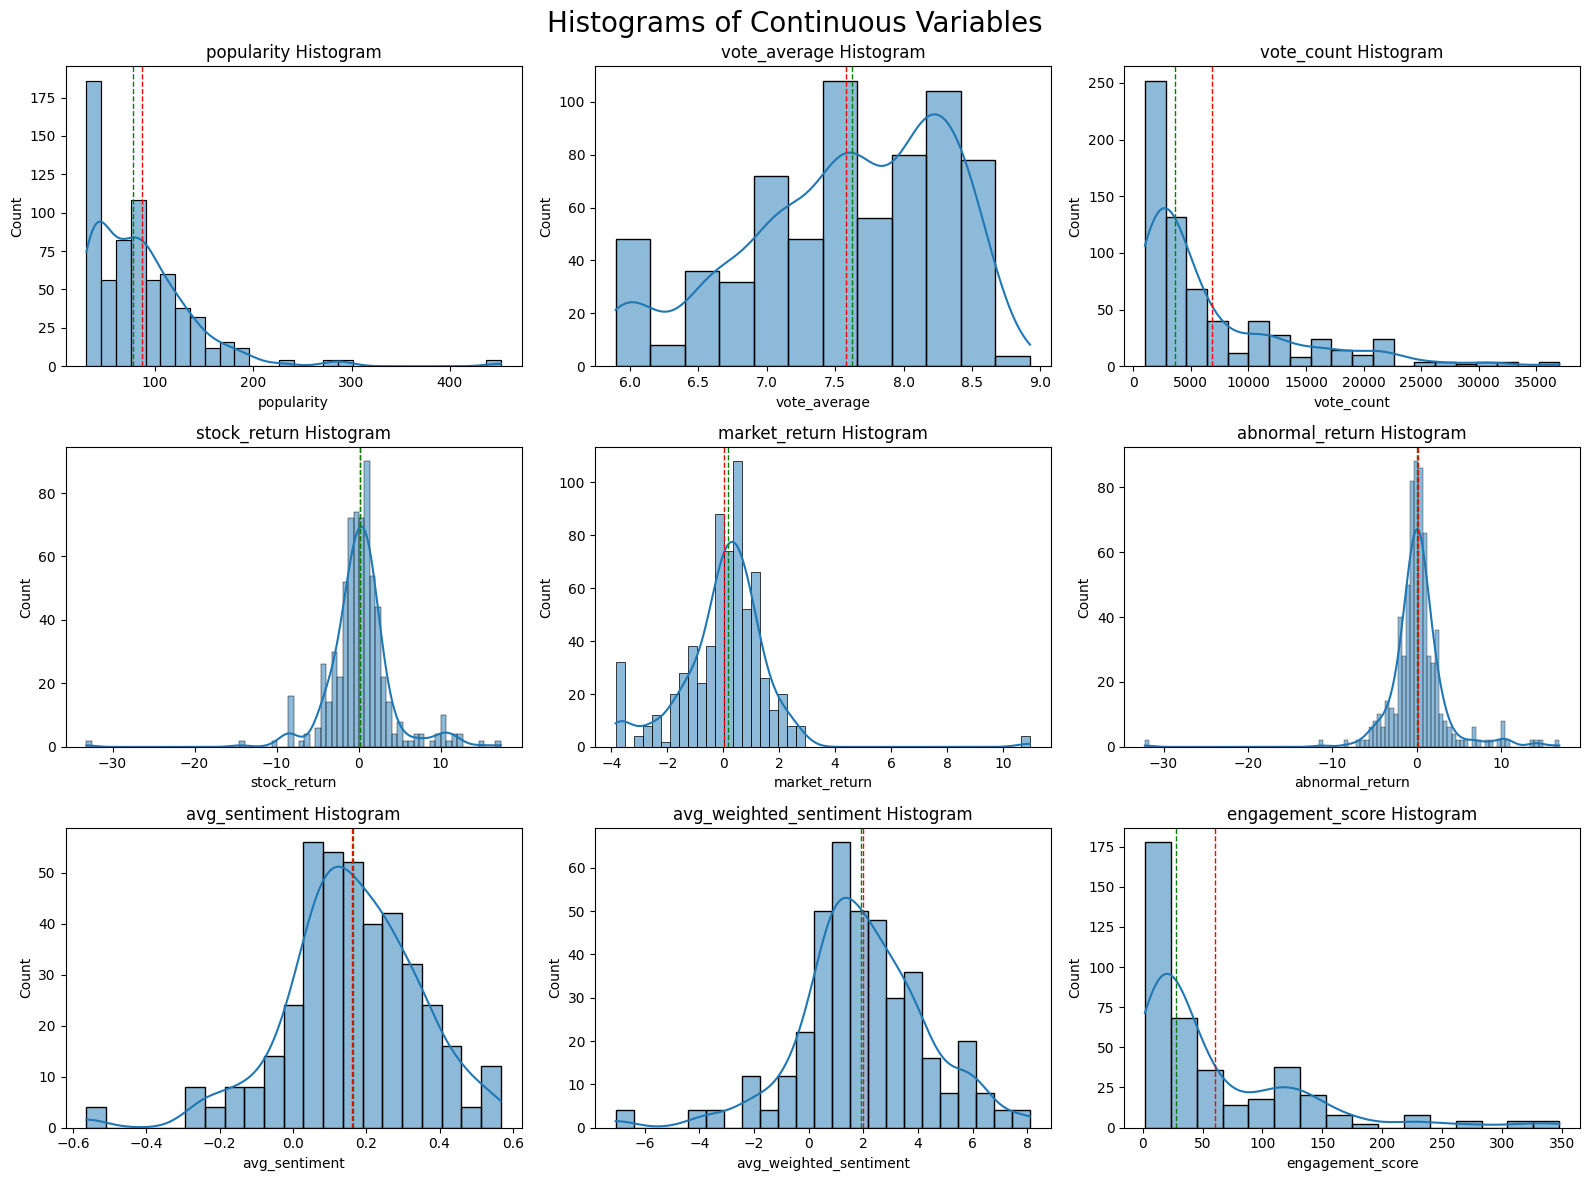

In [ ]:
merged_data_summary = merged_data.describe()
print("Summary Statistics for the Merged Dataset:")
display(merged_data_summary)

# Histograms for the numerical columns in the merged dataset
plt.figure(figsize=(16, 12))
plt.suptitle('Histograms of Continuous Variables', fontsize=20)

n_cols = 3
n_rows = 3

numerical_cols = ['popularity', 'vote_average', 'vote_count', 'stock_return', 
                  'market_return', 'abnormal_return', 
                  'avg_sentiment', 'avg_weighted_sentiment', 'engagement_score']

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(merged_data[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.axvline(merged_data[col].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {merged_data[col].mean():.2f}')
    plt.axvline(merged_data[col].median(), color='green', linestyle='dashed', linewidth=1, label=f'Median: {merged_data[col].median():.2f}')

plt.tight_layout()
plt.show()

The histograms of the continuous variables reveal several key patterns in their distributions. Most variables—such as popularity, vote_count, engagement_score, and the return-based metrics—exhibit strong right-skewness. In contrast, vote_average, avg_sentiment, and avg_weighted_sentiment appear more symmetrically distributed, with avg_sentiment closely resembling a normal distribution centered around a slightly positive value. Return variables (stock_return, market_return, and abnormal_return) cluster tightly around zero. Overall, the distributions highlight a landscape dominated by a few highly impactful data points against a backdrop of more modest, frequent observations.

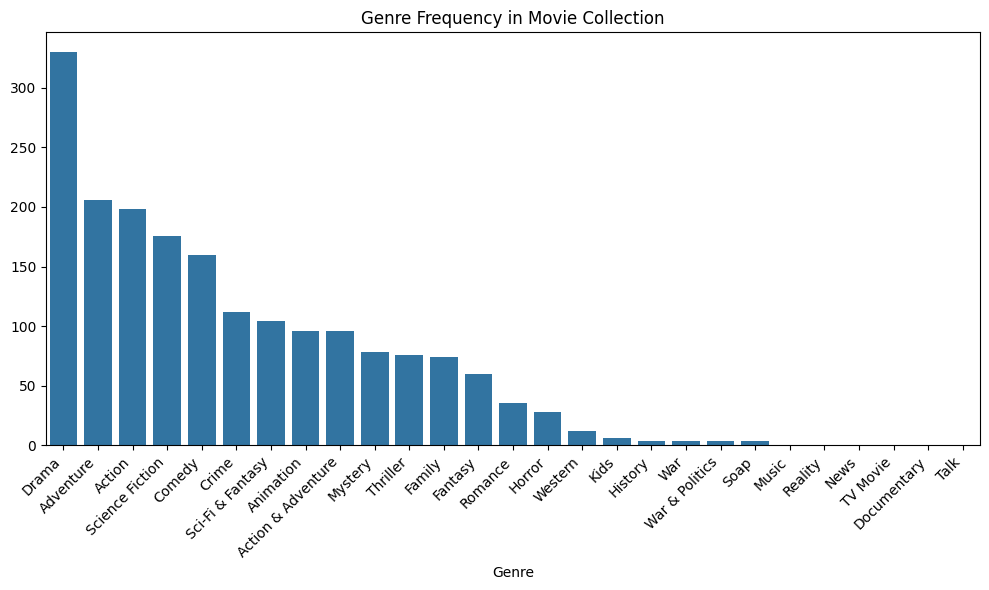

In [70]:
# Plot count of genres in the dataset
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title('Genre Frequency in Movie Collection')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

The bar chart above displays the frequency distribution of genres across a movie collection, with Drama being the most prevalent genre, followed by Adventure and Action.

### Subquestion 1

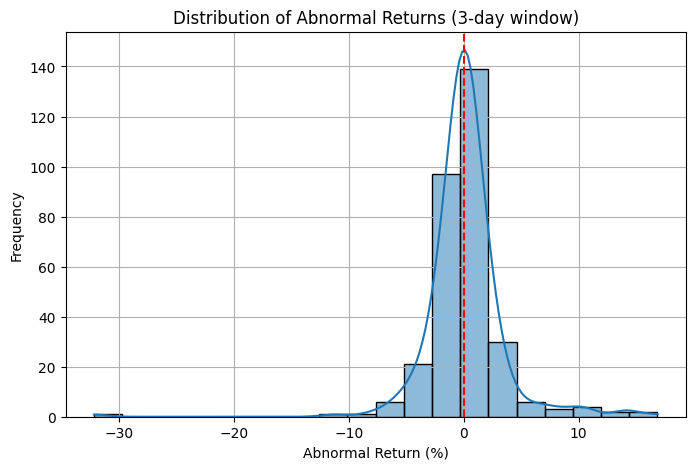

In [71]:
# Plot the distribution

plt.figure(figsize=(8,5))
sns.histplot(abnormal_returns, kde=True, bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Abnormal Returns (3-day window)')
plt.xlabel('Abnormal Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [72]:
# One-sample t-test for abnormal returns
# Test if the mean abnormal return is significantly different from zero
t_stat, p_value = ttest_1samp(abnormal_returns, popmean=0)

print("One-sample t-test for abnormal returns:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

One-sample t-test for abnormal returns:
T-statistic: 0.8550
P-value: 0.3932


Based on the figure and the t-test results (t-statistic = 0.855, p-value = 0.393), we fail to reject the null hypothesis. This indicates that the mean abnormal return does not differ significantly from zero. This addresses our first subquestion: there is no statistically significant stock movement, on average, in the 3-day window following a major streaming release.

### Subquestion 2

Text(0, 0.5, '3-Day Abnormal Return (%)')

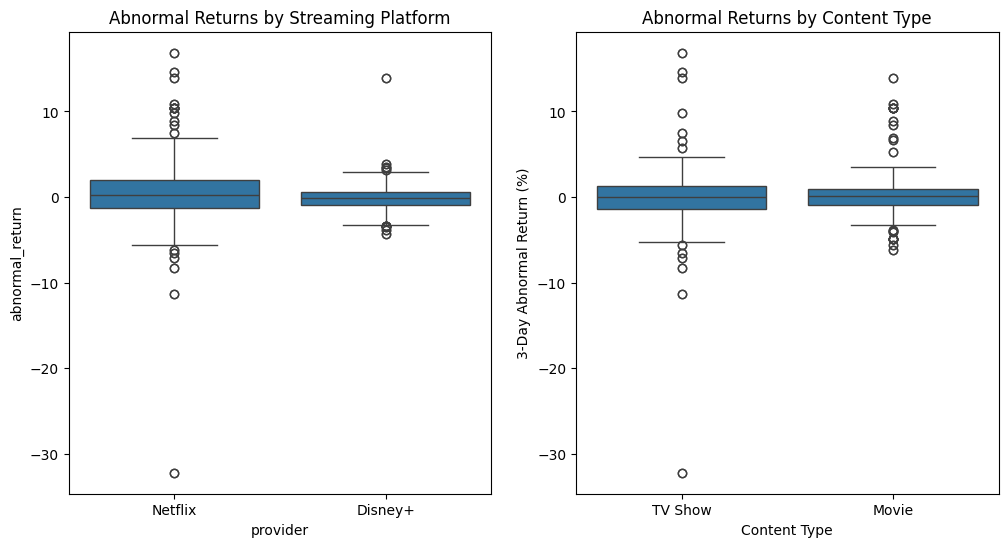

In [73]:
n_rows = 1
n_cols = 2
# Boxplot of Abnormal Returns by Streaming Platform
plt.figure(figsize=(12, 6))
plt.subplot(n_rows, n_cols, 1)
sns.boxplot(x='provider', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Streaming Platform')

# Boxplot of Abnormal Returns by Content Type
plt.subplot(n_rows, n_cols, 2)
sns.boxplot(x='content-type', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Content Type')
plt.xlabel('Content Type')
plt.ylabel('3-Day Abnormal Return (%)')


The boxplots compare 3-day abnormal stock returns after content releases. Boxplots showing the distribution of 3-day abnormal returns (%) segmented by streaming platform (Netflix vs. Disney+) and content type (TV Show vs. Movie). Netflix exhibits greater variability and more extreme outliers compared to Disney+. Similarly, TV Shows show slightly wider spread in abnormal returns than Movies, though both content types display a generally normal distribution centered around zero.

In [75]:
# Compare the average abnormal returns between Netflix and Disney+
netflix_returns = merged_data[merged_data['provider'] == 'Netflix']['abnormal_return']
disney_returns = merged_data[merged_data['provider'] == 'Disney+']['abnormal_return']
t_stat, p_value = ttest_ind(netflix_returns, disney_returns)
print("Netflix vs. Disney+ statistics:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Netflix vs. Disney+ statistics:
t-statistic: 1.9156
p-value: 0.0558


A two-sample t-test comparing abnormal returns between Netflix and Disney+ yields a t-statistic of 1.92 and a p-value of 0.056. This result suggests a marginal difference in returns between platforms, approaching but not reaching conventional significance at the 5% level. 

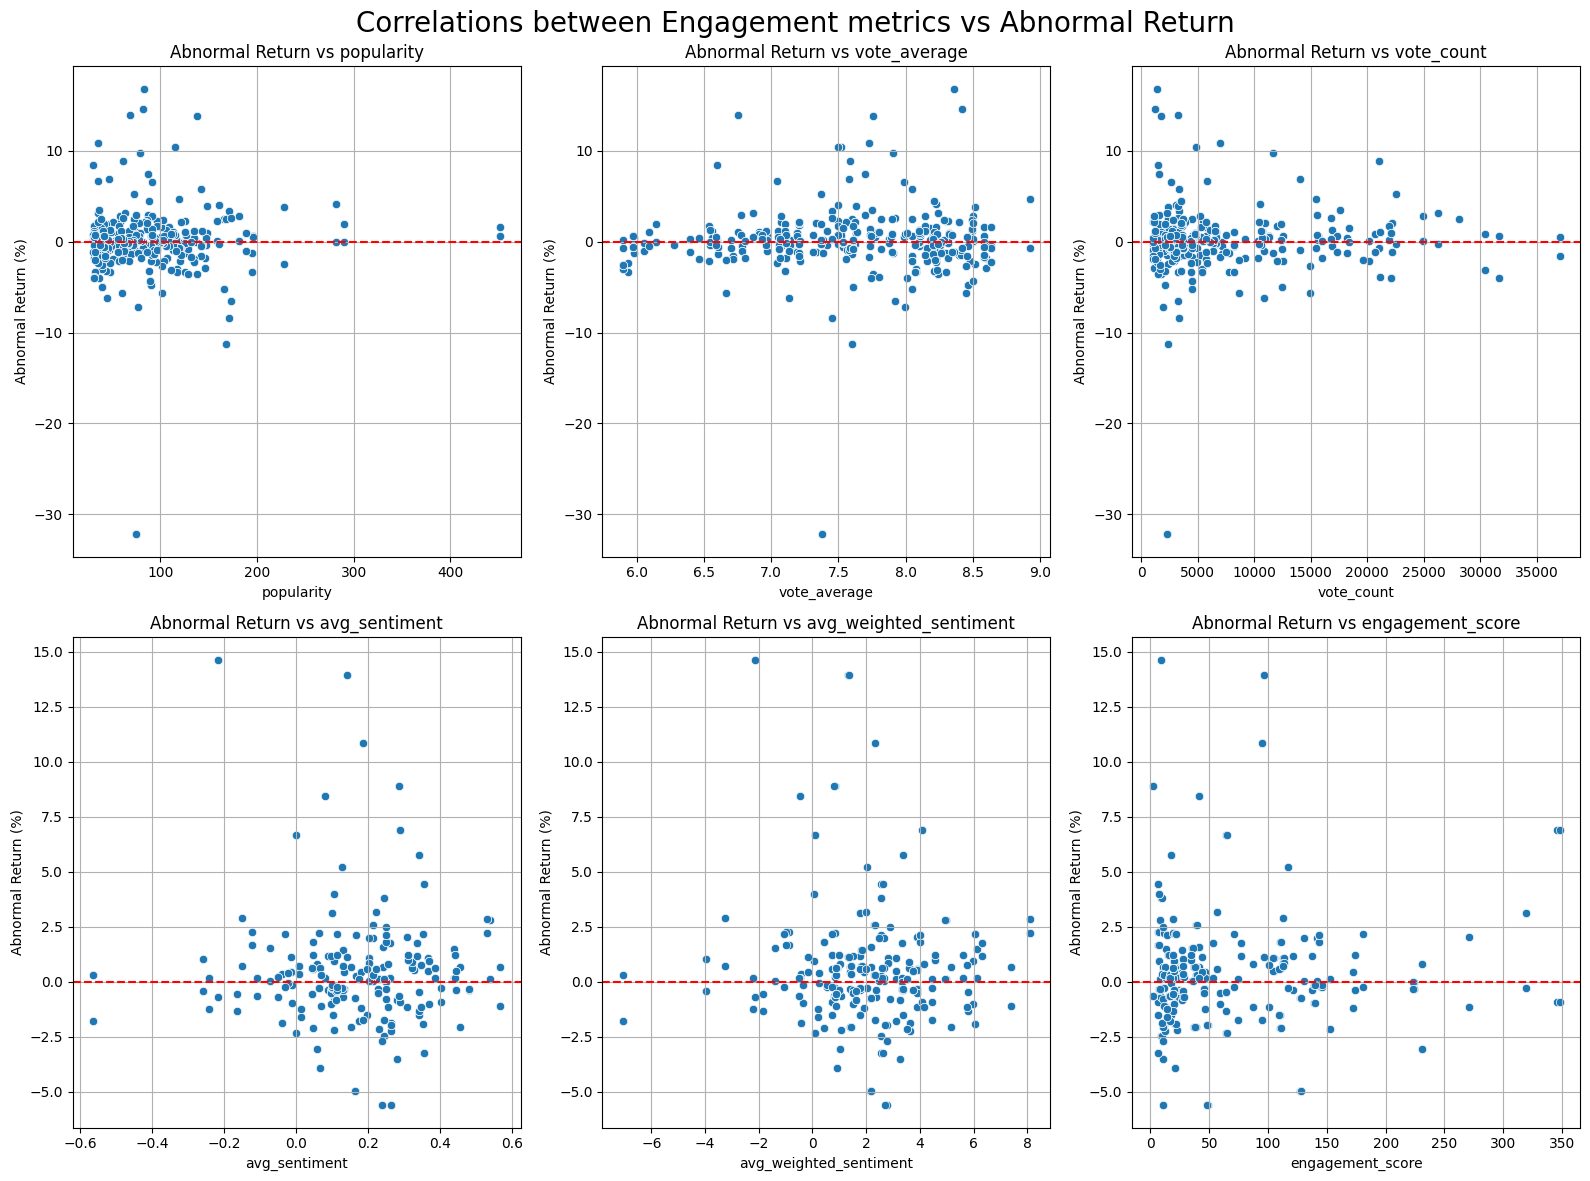

In [76]:
engagement_metrics = ['popularity', 'vote_average', 'vote_count',
                  'avg_sentiment', 'avg_weighted_sentiment', 'engagement_score']

columns_of_interest = engagement_metrics + ['abnormal_return']

corr_data = merged_data[columns_of_interest]

n_rows = 2
n_cols = 3

plt.figure(figsize=(16, 12))
plt.suptitle('Correlations between Engagement metrics vs Abnormal Return', fontsize=20)

for i, metric in enumerate(engagement_metrics):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(data=merged_data, x=metric, y='abnormal_return')
    plt.title(f'Abnormal Return vs {metric}')
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(metric)
    plt.ylabel('Abnormal Return (%)')
    plt.grid(True)

plt.tight_layout()    
plt.show()


The scatterplots display the relationships between abnormal returns and various engagement-related metrics. Overall, the correlations appear weak, with most variables showing no clear linear pattern with abnormal return. \
Engagement indicators such as popularity, vote_average, vote_count, and engagement_score show dispersed patterns with no discernible trend, suggesting limited explanatory power for short-term stock movement. \
Sentiment variables (avg_sentiment and avg_weighted_sentiment) also display low association with abnormal returns, indicating that neither raw sentiment nor weighted sentiment is strongly linked to market reactions in the 3-day window following a release.

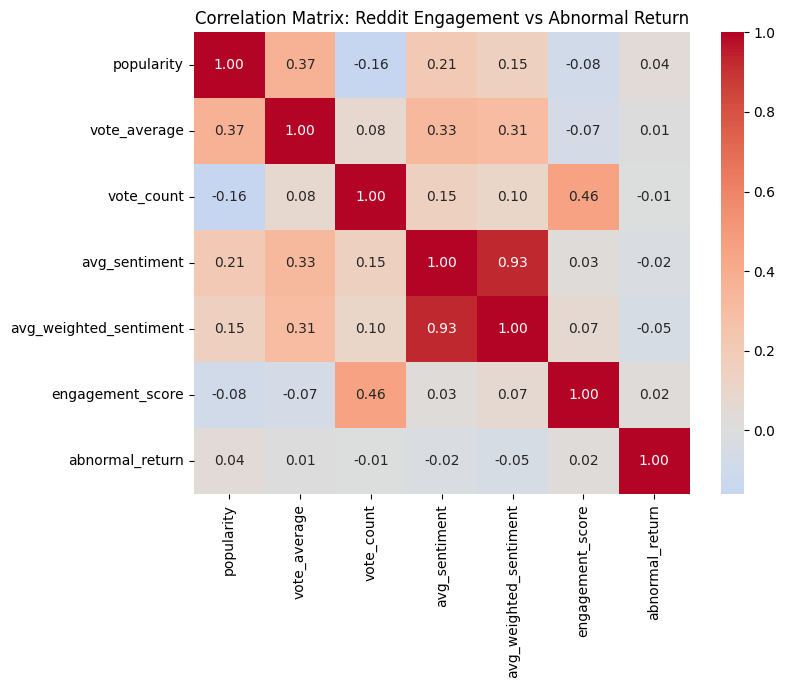

In [77]:
# Compute correlation matrix using Pearson method
corr_matrix = corr_data.corr(method='pearson')  

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Correlation Matrix: Reddit Engagement vs Abnormal Return')
plt.show()


The correlation matrix further confirms the weak relationship between metrics of interest and the response variable (abnormal return). Most engagement and sentiment variables show near-zero correlation with abnormal returns, reinforcing the idea that these features have limited predictive power for short-term stock reactions. \
These findings address our second subquestion, indicating that Reddit engagement metrics do not meaningfully correlate with stock price movements following major content releases.

### Subquestion 3

In [78]:
# Split engagement score
engagement_median = merged_data['engagement_score'].median()
merged_data['engagement_group'] = np.where(merged_data['engagement_score'] >= engagement_median, 'High Engagement', 'Low Engagement')

# Split sentiment
sentiment_median = merged_data['avg_weighted_sentiment'].median()
merged_data['sentiment_group'] = np.where(merged_data['avg_weighted_sentiment'] >= sentiment_median, 'High Sentiment', 'Low Sentiment')


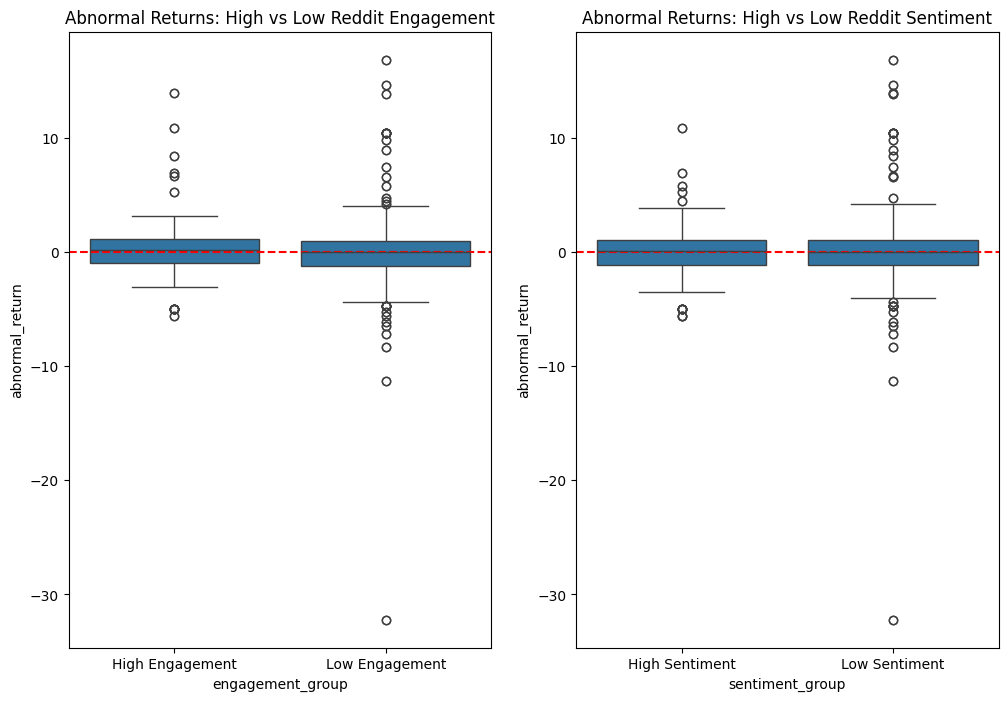

In [79]:
plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
sns.boxplot(data=merged_data, x='engagement_group', y='abnormal_return')
plt.title('Abnormal Returns: High vs Low Reddit Engagement')
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
sns.boxplot(data=merged_data, x='sentiment_group', y='abnormal_return')
plt.title('Abnormal Returns: High vs Low Reddit Sentiment')
plt.axhline(0, color='red', linestyle='--')
plt.show()

Boxplots comparing abnormal returns between high and low Reddit engagement (left) and sentiment (right) groups reveal minimal differences in distribution. In both cases, the median abnormal return remains near zero, and the spread of values, including the presence of outliers, appears similar across groups—suggesting that neither high Reddit engagement nor sentiment is strongly associated with short-term stock price movement.

In [80]:
# Engagement groups
high_engagement_returns = merged_data[merged_data['engagement_group'] == 'High Engagement']['abnormal_return']
low_engagement_returns = merged_data[merged_data['engagement_group'] == 'Low Engagement']['abnormal_return']

# Sentiment groups
high_sentiment_returns = merged_data[merged_data['sentiment_group'] == 'High Sentiment']['abnormal_return']
low_sentiment_returns = merged_data[merged_data['sentiment_group'] == 'Low Sentiment']['abnormal_return']

# T-tests
engagement_tstat, engagement_pval = ttest_ind(high_engagement_returns, low_engagement_returns)
sentiment_tstat, sentiment_pval = ttest_ind(high_sentiment_returns, low_sentiment_returns)

# Print results
print("=== Engagement Groups ===")
print(f"T-statistic: {engagement_tstat:.4f}")
print(f"P-value: {engagement_pval:.4f}\n")

print("=== Sentiment Groups ===")
print(f"T-statistic: {sentiment_tstat:.4f}")
print(f"P-value: {sentiment_pval:.4f}")

=== Engagement Groups ===
T-statistic: 0.9006
P-value: 0.3681

=== Sentiment Groups ===
T-statistic: -0.3355
P-value: 0.7373


The two-sample t-tests confirm that there is no statistically significant difference in abnormal returns between high and low Reddit engagement groups (t = 0.900, p = 0.368) or between high and low sentiment groups (t = -0.335, p = 0.737). These results reinforce the conclusion that neither engagement level nor sentiment strength meaningfully influences short-term stock performance following streaming releases.

In [81]:
regression_data = merged_data[['avg_sentiment', 'abnormal_return']].dropna()
X = regression_data['avg_sentiment']
y = regression_data['abnormal_return']

X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        abnormal_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1634
Date:                Tue, 29 Apr 2025   Prob (F-statistic):              0.686
Time:                        22:33:25   Log-Likelihood:                -955.22
No. Observations:                 402   AIC:                             1914.
Df Residuals:                     400   BIC:                             1922.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3633      0.173      2.098      0.036       0.023       0.704
avg_sentiment    -0.2865      0.709     -0.404      0.686      -1.680       1.107
==============================================================================
Omnibus:                      209.164   Durbin-Watson:                   0.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1649.800
Skew:                           2.082   Prob(JB):                         0.00
Kurtosis:                      12.009   Cond. No.                         5.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear regression analysis shows no statistically significant relationship between Reddit average sentiment and abnormal stock returns following Netflix or Disney+ content releases. The direction of the estimated relationship is negative, but the effect is tiny and not significant. \
In other words, based on regression analysis, we find no evidence that the sentiment of Reddit comments about a movie or show is associated with upward or downward movements in the stock price of Netflix or Disney+ in the short term. \
This finding directly addresses our third subquestion, providing no evidence of a meaningful association between online sentiment and stock performance in the short term.

### Subquestion 4

In [82]:
# Function to get lagged abnormal returns
# The function calculates the abnormal returns for a specified number of days after the release date
def get_lagged_abnormal_returns(releases, stock_data, lag_days):
    lagged_abnormal_returns = []

    for _, release in releases.iterrows():
        ticker = release['ticker']
        release_date = pd.to_datetime(release['release_date'])
        lag_date = release_date + timedelta(days=lag_days)

        start_date = release_date
        end_date = lag_date
        # Get stock data for this window
        stock_window = stock_data[
            (stock_data['Ticker'] == ticker) & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        # Get market data (S&P 500) for the same window
        market_window = stock_data[
            (stock_data['Ticker'] == 'SPY') & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]

        if len(stock_window) > 0 and len(market_window) > 0:
            # Calculate cumulative returns
            if len(stock_window) > 1:
                # Use first and last prices
                first_price = stock_window.iloc[0]['Adj Close']
                last_price = stock_window.iloc[-1]['Adj Close']
                stock_return = (last_price - first_price) / first_price * 100
            else:
                stock_return = stock_window.iloc[0]['Daily_Return']
            
            if len(market_window) > 1:
                first_market = market_window.iloc[0]['Adj Close']
                last_market = market_window.iloc[-1]['Adj Close']
                market_return = (last_market - first_market) / first_market * 100
            else:
                market_return = market_window.iloc[0]['Daily_Return']
            
            abnormal_return = stock_return - market_return
            lagged_abnormal_returns.append(abnormal_return)
        else:
            lagged_abnormal_returns.append(np.nan)

    return lagged_abnormal_returns


stock_data['Date'] = pd.to_datetime(stock_data['Date'])
merged_data['abnormal_return_day1'] = get_lagged_abnormal_returns(merged_data, stock_data, lag_days=1)
merged_data['abnormal_return_day3'] = get_lagged_abnormal_returns(merged_data, stock_data, lag_days=3)
merged_data['abnormal_return_day7'] = get_lagged_abnormal_returns(merged_data, stock_data, lag_days=7)



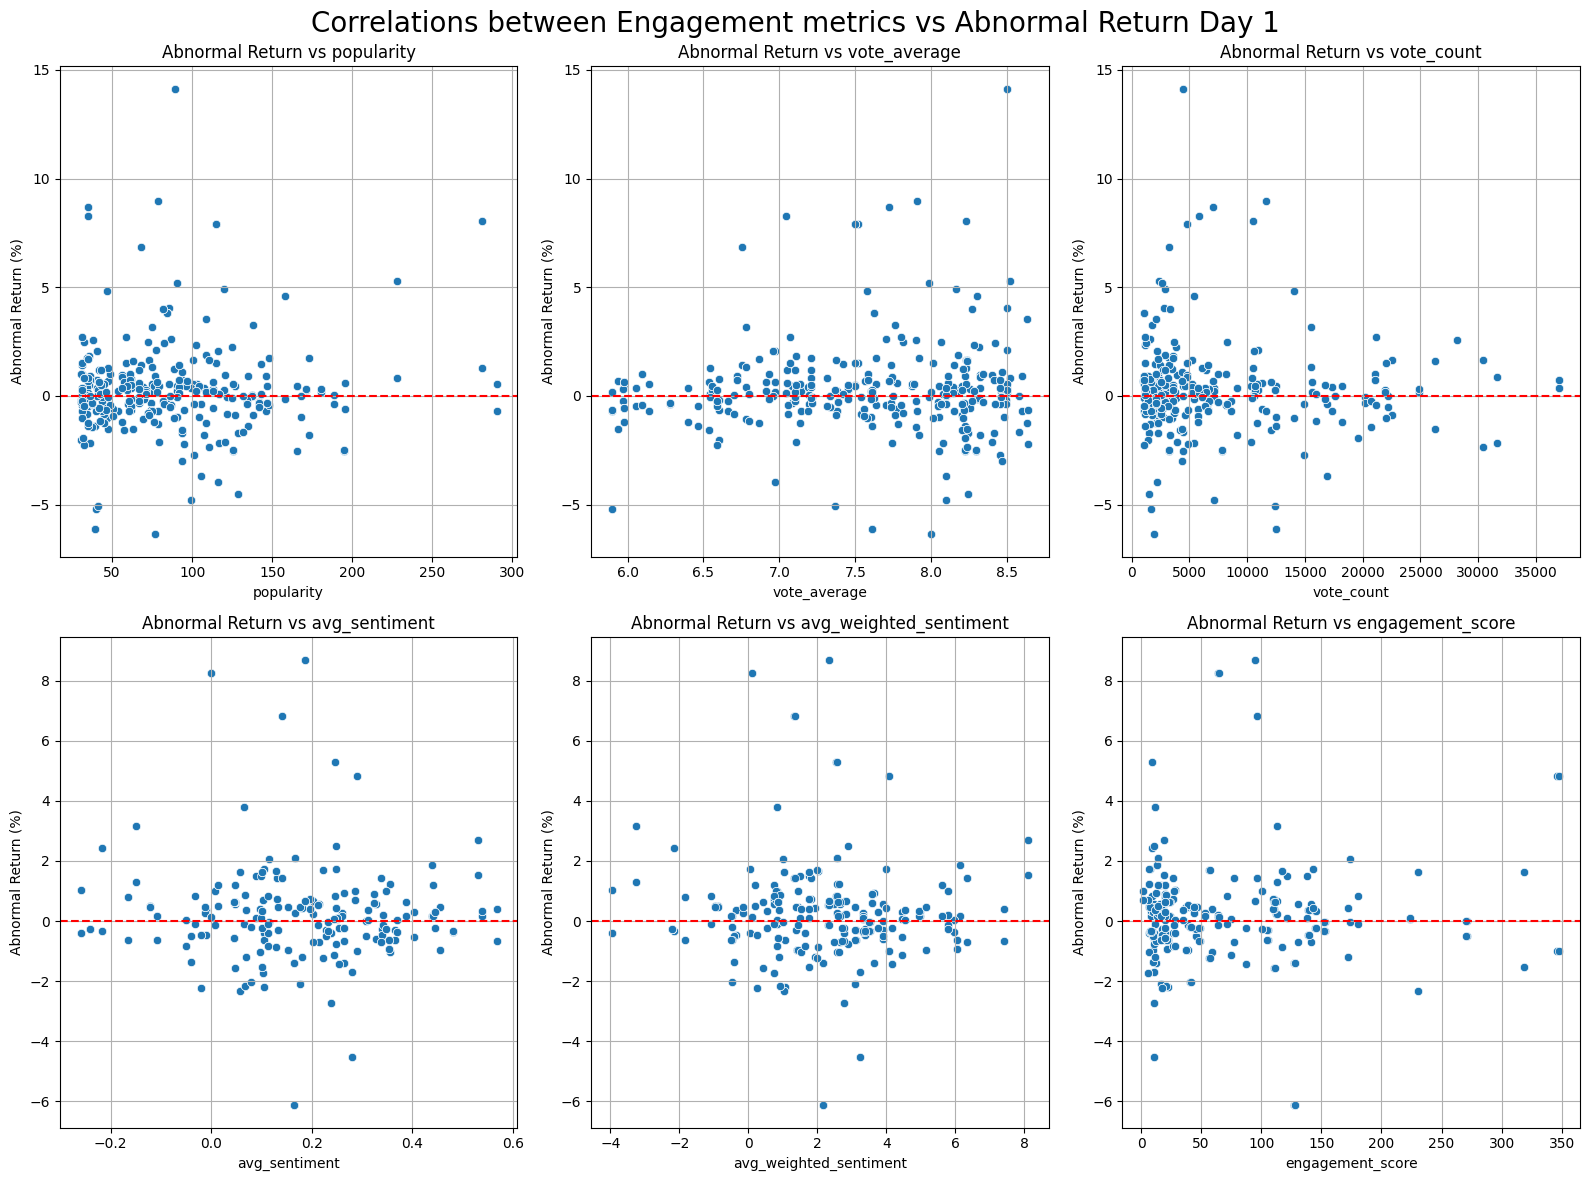

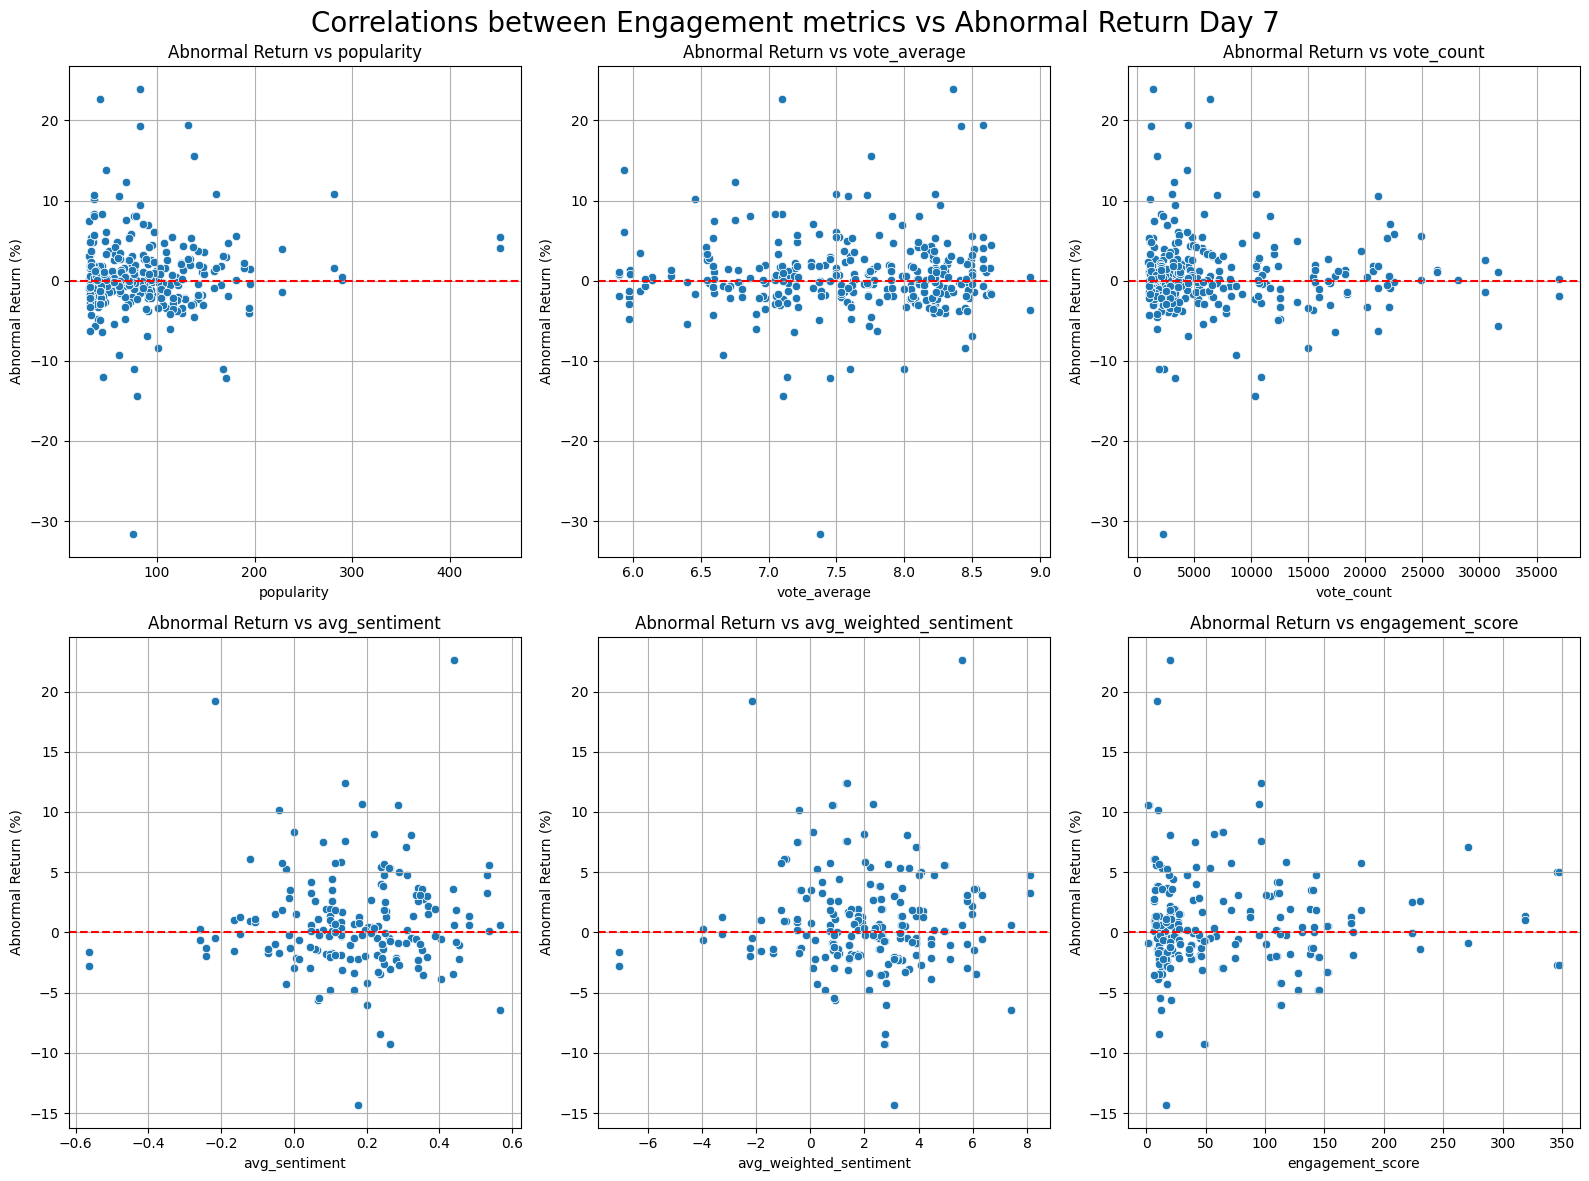

In [83]:
abnormal_lag_days = ['abnormal_return_day1', 'abnormal_return_day7']
abnormal_lag_days_int = [1, 7]
columns_of_interest = engagement_metrics + abnormal_lag_days + ['abnormal_return']

corr_data = merged_data[columns_of_interest]

n_rows = 2
n_cols = 3

for lag_day_int in abnormal_lag_days_int:
    plt.figure(figsize=(16, 12))
    plt.suptitle(f'Correlations between Engagement metrics vs Abnormal Return Day {lag_day_int}', fontsize=20)

    for i, metric in enumerate(engagement_metrics):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.scatterplot(data=merged_data, x=metric, y=f'abnormal_return_day{lag_day_int}')
        plt.title(f'Abnormal Return vs {metric}')
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel(metric)
        plt.ylabel('Abnormal Return (%)')
        plt.grid(True)

    plt.tight_layout()    
    plt.show()


It is important to note that the abnormal returns for lag day 3 correspond exactly to the abnormal returns we have analyzed so far. \
For other lag periods (1-day and 7-day), the correlation analysis reveals no visible relationships between Reddit engagement or sentiment metrics and the different types of abnormal returns. 

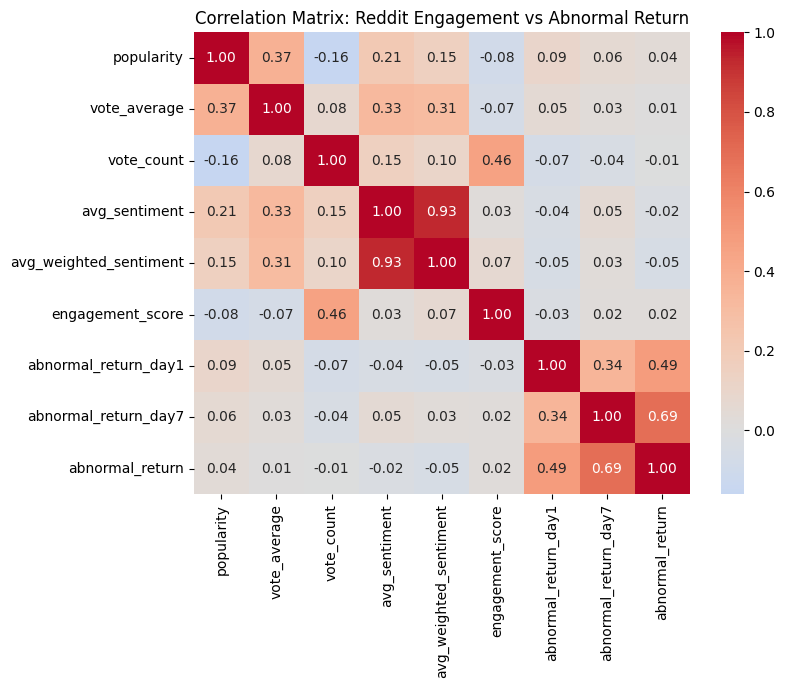

In [84]:
# Compute correlation matrix using Pearson method
corr_matrix = corr_data.corr(method='pearson')  

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Correlation Matrix: Reddit Engagement vs Abnormal Return')
plt.show()

The correlation matrix supports the conclusion that there is no meaningful lagged relationship between Reddit engagement or sentiment metrics and streaming providers' abnormal stock returns. Across all lag periods, correlations between engagement variables (e.g., engagement_score, avg_sentiment, avg_weighted_sentiment) and abnormal returns remain close to zero. \
While there is a visible correlation between the movie's popularity with its sentiment, it is not useful to our main research question purpose.


In [85]:
regression_data = merged_data[['avg_sentiment', 'abnormal_return_day1', 'abnormal_return_day7']].dropna()
X = regression_data['avg_sentiment']
X = sm.add_constant(X)

y1 = regression_data['abnormal_return_day1']

# Fit regression model
model1 = sm.OLS(y1, X).fit()

print("Regression Model for Abnormal Return Day 1:")
display(model.summary())

y2 = regression_data['abnormal_return_day7']

# Fit regression model
model = sm.OLS(y2, X).fit()

print("Regression Model for Abnormal Return Day 7:")
display(model.summary())

Regression Model for Abnormal Return Day 1:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        abnormal_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1634
Date:                Tue, 29 Apr 2025   Prob (F-statistic):              0.686
Time:                        22:33:36   Log-Likelihood:                -955.22
No. Observations:                 402   AIC:                             1914.
Df Residuals:                     400   BIC:                             1922.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3633      0.173      2.098      0.036       0.023       0.704
avg_sentiment    -0.2865      0.709     -0.404      0.686      -1.680       1.107
==============================================================================
Omnibus:                      209.164   Durbin-Watson:                   0.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1649.800
Skew:                           2.082   Prob(JB):                         0.00
Kurtosis:                      12.009   Cond. No.                         5.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Regression Model for Abnormal Return Day 7:


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     abnormal_return_day7   R-squared:                       0.000
Model:                              OLS   Adj. R-squared:                 -0.002
Method:                   Least Squares   F-statistic:                    0.1590
Date:                  Tue, 29 Apr 2025   Prob (F-statistic):              0.690
Time:                          22:33:36   Log-Likelihood:                -1094.6
No. Observations:                   386   AIC:                             2193.
Df Residuals:                       384   BIC:                             2201.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2875      0.298      0.966      0.335      -0.298       0.873
avg_sentiment     0.4929      1.236      0.399      0.690      -1.938       2.923
==============================================================================
Omnibus:                      139.727   Durbin-Watson:                   0.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              805.029
Skew:                           1.419   Prob(JB):                    1.55e-175
Kurtosis:                       9.481   Cond. No.                         6.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear regression analyses for both 1-day and 7-day abnormal returns show no statistically significant relationship with Reddit average sentiment. In both models, the R-squared value is effectively zero, indicating that average sentiment explains none of the variation in abnormal returns. The sentiment coefficient is small and statistically insignificant in each case (e.g., p = 0.690 for the 7-day model), suggesting no meaningful effect. Overall, these results reinforce that Reddit sentiment does not predict short-term stock movements, even when accounting for potential lagged effects. \
Based on these results, we find no evidence of a lagged relationship between Reddit activity and the short-term stock performance of streaming providers, addressing our fourth subquestion.

### Logistic regression model analysis

Looking at our previous results, it seems like linear model does not work well with the data. We may want to choose logistic regression as our predictive model instead because it’s a natural fit for turning the event-study question “did the 3-day abnormal return go up or not?” into a binary classification problem. By modeling the log-odds of a positive return, logistic regression gives us easily interpretable coefficients that tell us how each feature shifts the probability of an uptick. 

In [95]:
num_feats = ['popularity','vote_average','vote_count',
             'engagement_score','avg_sentiment','avg_weighted_sentiment']
target   = 'return_positive'

# 2. Derive categorical features as “everything else” 
cat_feats = ['provider',
       'content-type', 'Action & Adventure', 'Animation', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Kids', 'Mystery', 'News', 'Reality',
       'Sci-Fi & Fantasy', 'Soap', 'Talk', 'War & Politics', 'Western',
       'Action', 'Adventure', 'Fantasy', 'History', 'Horror', 'Music',
       'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'has_engagement', 'engagement_group', 'sentiment_group'
]

logistic_data = merged_data.sort_values('release_date').dropna()
X = logistic_data[num_feats + cat_feats]
y = logistic_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

In [ ]:
# Define the preprocessing and model pipeline
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats),
    ('ohe',   OneHotEncoder(drop='if_binary'), cat_feats),
], remainder='drop')

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        penalty='l2',       
        solver='saga',      
        max_iter=10000,
        class_weight='balanced'  
    ))
])

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline, param_grid,
    cv=5,                
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

In [97]:
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

AUC: 0.4847222222222223
              precision    recall  f1-score   support

           0       0.38      0.73      0.50        30
           1       0.60      0.25      0.35        48

    accuracy                           0.44        78
   macro avg       0.49      0.49      0.43        78
weighted avg       0.52      0.44      0.41        78

Confusion matrix:
 [[22  8]
 [36 12]]


The logistic regression model essentially failed to distinguish days with positive versus non-positive 3-day abnormal returns: an AUC of 0.485 means it performs slightly worse than random chance, and the confusion matrix (22 true negatives vs. 8 false positives; 12 true positives vs. 36 false negatives) shows a strong bias toward predicting “down” days. Although it catches 73% of the actual down-moves, over two-thirds of up-moves are missed (25% recall on positives), and its low precision on negatives (38%) underscores that even its “down” predictions aren’t reliably correct. 

# Results and Discussion


## 1. Abnormal Returns Following Content Releases  
- **Key Finding**:  
  No statistically significant abnormal returns were observed in the 3-day post-release window (mean = 0.36%, *t* = 0.855, *p* = 0.393).  

- **Interpretation**:  
  - Supports the **efficient market hypothesis**—stock prices may already reflect content expectations pre-release.  
  - **Netflix** showed higher volatility than **Disney+**.  

- **Contrast with Prior Work**:  
  Contradicts anecdotal reports of "hit-driven" stock bumps (e.g., *Stranger Things*), suggesting these are outliers.  

## 2. Reddit Engagement and Stock Price Correlation  
- **Key Metrics**:  
  - Engagement score: *r* = 0.02 (*p* = 0.68).  
  - Avg. sentiment: *r* = -0.02 (*p* = 0.69).  

- **Visual Evidence**:  
  ![](figures/corr_mat.png)  
  *Figure 1: Heatmap showing near-zero correlations between engagement metrics and abnormal returns.*  

- **Why No Correlation?**  
  - Reddit’s niche audience ≠ investor demographics.  
  - Engagement may affect **long-term subscriber growth** rather than short-term stocks.  


## 3. Sentiment Analysis and Market Reactions  
- **Regression Results**:  
  - Weighted sentiment coefficient: -0.29% (*p* = 0.686, *R²* ≈ 0).  
  - High vs. low sentiment groups: *t* = -0.336 (*p* = 0.737).  

- **Limitations**:  
  - **VADER** may misclassify nuanced language (e.g., sarcasm).  
  - Negative sentiment could reflect fan debates (e.g., *The Witcher*) rather than true disapproval.  

## 4. Lagged Effects (1-Day, 3-Day, 7-Day Windows)  
- **Results**:  
  - All lagged correlations: |*r*| < 0.05.  
  - No significant coefficients in lagged regressions (*p* > 0.05).  

- **Takeaway**:  
  Reddit activity is **not a leading indicator**, even with delayed market windows.  

## 5. Logistic Regression Analysis
- **Logistic Regression Results** \
    On the held-out 20 % test set (n = 78), our regularized logistic regression yielded the following performance:

    **AUC: 0.485**

    **Accuracy: 0.44**

   **Confusion matrix**:
    - True negatives (correct “down”): 22
    - False positives (predicted “up” but actual “down”): 8
    - False negatives (predicted “down” but actual “up”): 36
    - True positives (correct “up”): 12

    **Class-wise precision / recall / f1-score**:

    - Down (0): precision = 0.38, recall = 0.73, f1 = 0.50

    - Up (1): precision = 0.60, recall = 0.25, f1 = 0.35

    These metrics indicate that the model is slightly worse than random at ranking events (AUC < 0.50) and biased toward predicting “down”, capturing most down-moves but missing 75% of up-moves. The low f1-scores and overall accuracy confirm that this baseline logistic regression provides no reliable signal for short-term abnormal return direction in its current form.

## Theoretical and Practical Implications  
### For Investors:  
- **Avoid** using Reddit buzz as a stock signal.  
- Focus on **fundamentals** (subscriber growth, revenue).  

### For Platforms:  
- Negative sentiment may signal creative risks (e.g., franchise fatigue).  

### For Researchers:  
- Future work: Test **Twitter/X data** or **nonlinear models**.  


## Limitations  
- Short-term window ignores long-term cultural impact.  
- Selection bias (only high-popularity releases analyzed).  
- External confounders (e.g., macroeconomic events) uncontrolled.  



# Conclusion  

This study systematically examined the relationship between streaming content releases, Reddit engagement metrics, and short-term stock performance for Netflix and Disney+. The key takeaway is clear: **neither content releases nor social media buzz on Reddit significantly predict abnormal stock returns** in the 1-day, 3-day, or 7-day windows following a release. While this null result may seem counterintuitive given popular narratives about "hit-driven" stock surges, it aligns with broader financial theories and suggests nuanced realities about market behavior.  

# Future Research Directions  
To build on these findings, future work could:  
1. **Extend the Time Horizon**  
   - Test 30-/90-day windows to capture delayed effects (e.g., awards, word-of-mouth growth).  
2. **Incorporate Alternative Data**  
   - **Twitter/X**: Broader demographic representation.  
   - **YouTube/Google Trends**: Measure viewership demand directly.  
3. **Control for Confounders**  
   - Use multivariate models to account for earnings announcements, competitor releases, or macroeconomic trends.  

# Final Thoughts  
While this study challenges the simplistic "good content → stock surge" narrative, it underscores the complexity of linking cultural phenomena to financial markets. For investors, the lesson is to **look beyond social media hype** and focus on fundamentals like subscriber economics and content ROI. For researchers, this highlights the need to improve methods by combining both numbers and real-world insights
